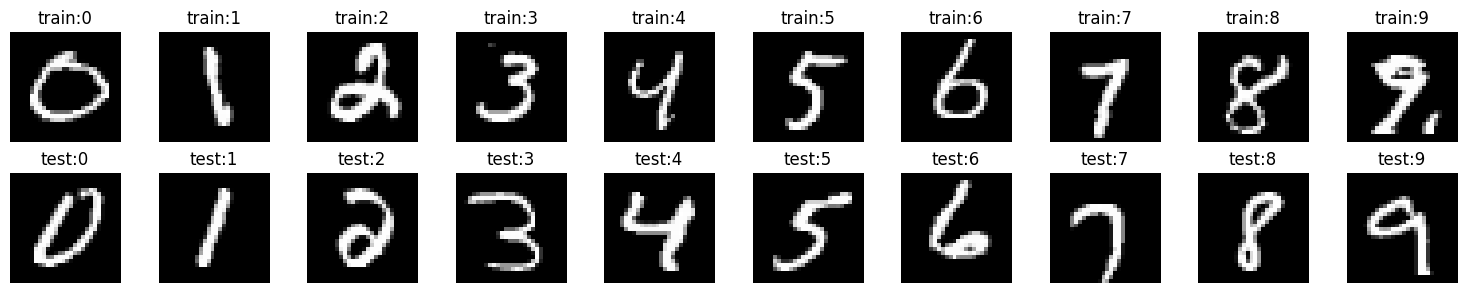

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_set = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_set = datasets.MNIST(root="data", train=False, download=True, transform=transform)

batch_size = 256
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

classes = list(range(10))
g = torch.Generator()

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for row, ds in enumerate([train_set, test_set]):
    targets = ds.targets
    for c in classes:
        idxs = torch.nonzero(targets == c, as_tuple=False).view(-1)
        ix = idxs[torch.randint(0, idxs.shape[0], (1,), generator=g)].item()
        img, lab = ds[ix]
        axes[row, c].imshow(img.squeeze(0), cmap="gray")
        axes[row, c].set_title(f"{'train' if row == 0 else 'test'}:{lab}")
        axes[row, c].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn

model = nn.Sequential(
    # Proceso de convolución
    nn.Conv2d(1, 6, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(6, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    # Red neuronal fully-connected
    nn.Linear(16 * 7 * 7, 64),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(32, 10),
).to(device)

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

epochs = 10
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# Historiales para monitorear la evolución por época
train_loss_hist = []  # Pérdida promedio en train por época
test_loss_hist = []  # Pérdida promedio en test por época
acc_hist_train = []  # Accuracy en train por época
acc_hist_test = []  # Accuracy en test por época
f1_hist_train = []  # F1 macro en train por época
f1_hist_test = []  # F1 macro en test por época

for ep in range(epochs):
    # Modo entrenamiento:
    model.train()
    running_loss = 0.0  # Acumulador de pérdida en train para promediar al final
    num_batches = 0

    # Bucle de mini batches sobre el loader de entrenamiento
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)  # Mover batch a CPU o GPU
        logits = model(xb)  # Forward
        loss = F.cross_entropy(logits, yb)  # Cálculo de pérdida de clasificación

        opt.zero_grad(set_to_none=True)  # Limpia gradientes acumulados
        loss.backward()  # Backprop
        opt.step()  # Actualización de pesos con Adam

        running_loss += loss.item()  # Suma de pérdidas para promediar
        num_batches += 1

    # Promedio de pérdida de entrenamiento para la época actual
    epoch_train_loss = running_loss / max(1, num_batches)
    train_loss_hist.append(epoch_train_loss)

    # Evaluación de métricas en TRAIN para registrar curvas comparables
    model.eval()
    with torch.no_grad():
        preds_train = []
        trues_train = []
        running_loss_te = 0.0
        num_batches_te = 0

        # Para medir loss en test y métricas en train y test, recorremos ambos dataloaders
        # 1) Métricas en TRAIN
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1)
            preds_train.append(pred.cpu())
            trues_train.append(yb.cpu())

        y_pred_tr = torch.cat(preds_train).numpy()
        y_true_tr = torch.cat(trues_train).numpy()
        acc_tr = accuracy_score(y_true_tr, y_pred_tr)  # Accuracy train
        f1_tr = f1_score(y_true_tr, y_pred_tr, average="macro")  # F1 macro train
        acc_hist_train.append(acc_tr)
        f1_hist_train.append(f1_tr)

        # 2) Pérdida y métricas en TEST
        preds_test = []
        trues_test = []
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss_te = F.cross_entropy(logits, yb)  # Loss por batch en test
            running_loss_te += loss_te.item()
            num_batches_te += 1
            pred = logits.argmax(dim=1)
            preds_test.append(pred.cpu())
            trues_test.append(yb.cpu())

        epoch_test_loss = running_loss_te / max(1, num_batches_te)  # Loss promedio test
        test_loss_hist.append(epoch_test_loss)

        y_pred_te = torch.cat(preds_test).numpy()
        y_true_te = torch.cat(trues_test).numpy()
        acc_te = accuracy_score(y_true_te, y_pred_te)  # Accuracy test
        f1_te = f1_score(y_true_te, y_pred_te, average="macro")  # F1 macro test
        acc_hist_test.append(acc_te)
        f1_hist_test.append(f1_te)

    # Impresión de métricas por época para trazabilidad en consola
    print(
        f"Epoca {ep + 1:03d} | "
        f"Train Loss: {epoch_train_loss:.4f}  Acc: {acc_tr:.4f}  F1_macro: {f1_tr:.4f}  ||  "
        f"Test Loss: {epoch_test_loss:.4f}   Acc: {acc_te:.4f}  F1_macro: {f1_te:.4f}"
    )

Epoca 001 | Train Loss: 1.0147  Acc: 0.9124  F1_macro: 0.9117  ||  Test Loss: 0.2766   Acc: 0.9203  F1_macro: 0.9194
Epoca 002 | Train Loss: 0.3960  Acc: 0.9506  F1_macro: 0.9502  ||  Test Loss: 0.1607   Acc: 0.9519  F1_macro: 0.9515
Epoca 003 | Train Loss: 0.2672  Acc: 0.9638  F1_macro: 0.9637  ||  Test Loss: 0.1141   Acc: 0.9634  F1_macro: 0.9632
Epoca 004 | Train Loss: 0.2192  Acc: 0.9721  F1_macro: 0.9719  ||  Test Loss: 0.0872   Acc: 0.9709  F1_macro: 0.9707
Epoca 005 | Train Loss: 0.1814  Acc: 0.9769  F1_macro: 0.9768  ||  Test Loss: 0.0714   Acc: 0.9771  F1_macro: 0.9770
Epoca 006 | Train Loss: 0.1610  Acc: 0.9777  F1_macro: 0.9776  ||  Test Loss: 0.0745   Acc: 0.9769  F1_macro: 0.9767
Epoca 007 | Train Loss: 0.1414  Acc: 0.9811  F1_macro: 0.9810  ||  Test Loss: 0.0605   Acc: 0.9805  F1_macro: 0.9804
Epoca 008 | Train Loss: 0.1303  Acc: 0.9825  F1_macro: 0.9824  ||  Test Loss: 0.0555   Acc: 0.9816  F1_macro: 0.9815
Epoca 009 | Train Loss: 0.1265  Acc: 0.9849  F1_macro: 0.9848  |

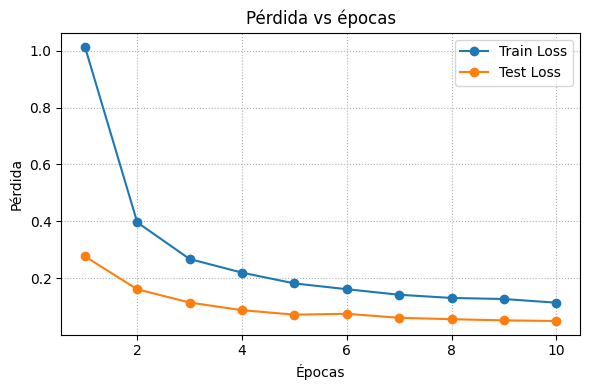

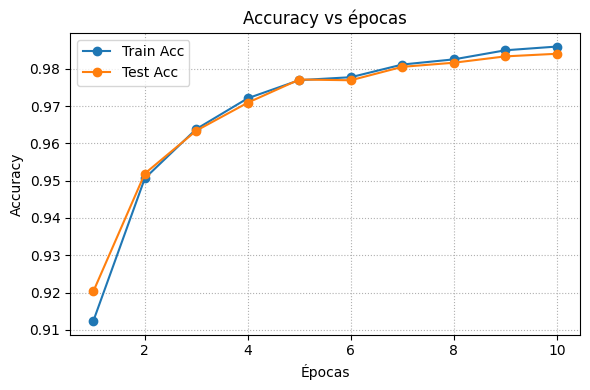

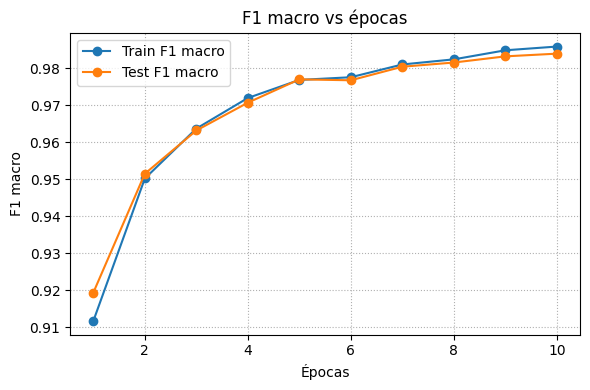

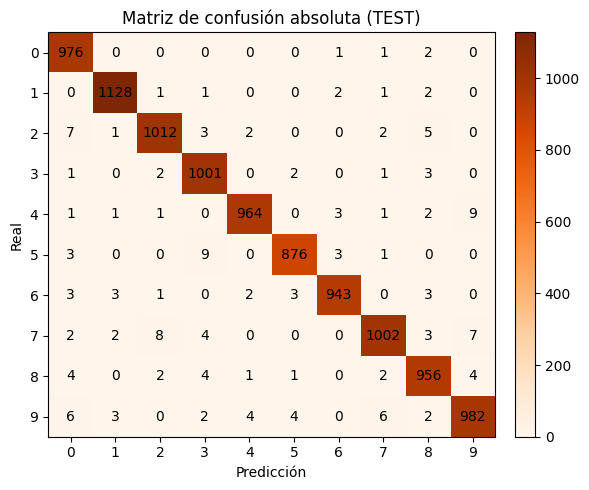

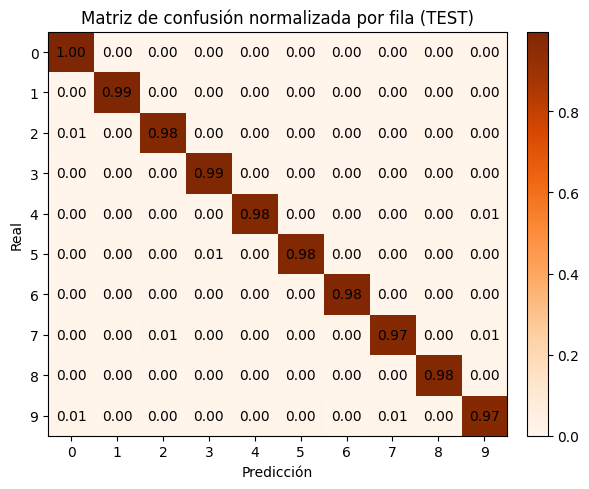

In [ ]:
# ================================
# Gráficas y matrices de confusión
# ================================

# Rango de épocas para el eje x
ep_range = np.arange(1, epochs + 1)

# 1) Curvas de pérdida por época
plt.figure(figsize=(6, 4))
plt.plot(ep_range, train_loss_hist, marker="o", label="Train Loss")
plt.plot(ep_range, test_loss_hist, marker="o", label="Test Loss")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Pérdida vs épocas")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Curvas de accuracy por época
plt.figure(figsize=(6, 4))
plt.plot(ep_range, acc_hist_train, marker="o", label="Train Acc")
plt.plot(ep_range, acc_hist_test, marker="o", label="Test Acc")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Accuracy vs épocas")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Curvas de F1 macro por época
plt.figure(figsize=(6, 4))
plt.plot(ep_range, f1_hist_train, marker="o", label="Train F1 macro")
plt.plot(ep_range, f1_hist_test, marker="o", label="Test F1 macro")
plt.xlabel("Épocas")
plt.ylabel("F1 macro")
plt.title("F1 macro vs épocas")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Matrices de confusión en TEST: absoluta y normalizada por fila
model.eval()
with torch.no_grad():
    preds_test = []
    trues_test = []
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        pred = logits.argmax(dim=1)
        preds_test.append(pred.cpu())
        trues_test.append(yb.cpu())
y_pred_te = torch.cat(preds_test).numpy()
y_true_te = torch.cat(trues_test).numpy()

# Etiquetas de clase para el eje
classes = np.unique(np.concatenate([y_true_te, y_pred_te]))
tick_labels = [str(c) for c in classes]


# Función auxiliar para pintar la matriz con anotaciones visibles
def plot_cm(cm, title, fmt_vals, cmap="Oranges"):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(tick_labels, rotation=0)
    ax.set_yticklabels(tick_labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, fmt_vals(i, j), ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


# Matriz absoluta
cm_abs = confusion_matrix(y_true_te, y_pred_te, labels=classes)
plot_cm(
    cm_abs, title="Matriz de confusión absoluta (TEST)", fmt_vals=lambda i, j: f"{cm_abs[i, j]:d}"
)

# Matriz normalizada por fila
cm_norm = confusion_matrix(y_true_te, y_pred_te, labels=classes, normalize="true")
plot_cm(
    cm_norm,
    title="Matriz de confusión normalizada por fila (TEST)",
    fmt_vals=lambda i, j: f"{cm_norm[i, j]:.2f}",
)

In [ ]:
from torchinfo import summary

summary(model, input_size=(batch_size, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [256, 10]                 --
├─Conv2d: 1-1                            [256, 6, 28, 28]          60
├─ReLU: 1-2                              [256, 6, 28, 28]          --
├─MaxPool2d: 1-3                         [256, 6, 14, 14]          --
├─Conv2d: 1-4                            [256, 16, 14, 14]         880
├─ReLU: 1-5                              [256, 16, 14, 14]         --
├─MaxPool2d: 1-6                         [256, 16, 7, 7]           --
├─Flatten: 1-7                           [256, 784]                --
├─Linear: 1-8                            [256, 64]                 50,240
├─ReLU: 1-9                              [256, 64]                 --
├─Dropout: 1-10                          [256, 64]                 --
├─Linear: 1-11                           [256, 32]                 2,080
├─ReLU: 1-12                             [256, 32]                 --
├─Dropo

In [ ]:
from google.colab import output
import torch
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()


def mnist_predict(pixels):
    x = np.array(pixels, dtype=np.float32).reshape(1, 1, 28, 28)
    t = torch.from_numpy(x).to(device)
    with torch.no_grad():
        logits = model(t)
        probs = F.softmax(logits, dim=1).squeeze().tolist()
        pred = int(np.argmax(probs))
    return {"pred": pred, "probs": probs}


output.register_callback("mnist_predict", mnist_predict)
print("Callback mnist_predict registrado.")

Callback mnist_predict registrado.


In [ ]:
from IPython.display import HTML, display

display(
    HTML("""
<div id="mnist-ui" style="font-family: Inter, system-ui, -apple-system, Segoe UI, Roboto, Arial; max-width: 960px; margin: 10px auto;">
  <div style="display: grid; grid-template-columns: 360px 1fr; gap: 16px; align-items: start;">
    <div>

      <div style="display:flex; align-items:center; gap:10px; margin:6px 0 10px;">
        <label for="stroke" style="font-size:14px;">Grosor:</label>
        <input id="stroke" type="range" min="4" max="48" step="1" value="18" style="width:170px;">
        <button id="clearBtn" style="padding:8px 12px; border:1px solid #ddd; border-radius:10px; background:#fff; cursor:pointer;">Limpiar</button>
        <button id="predictBtn" style="padding:8px 12px; border:1px solid #222; border-radius:10px; background:#111; color:#fff; cursor:pointer;">Predecir</button>
      </div>

      <div style="margin:6px 0 14px;">
        <button id="downloadBtn" style="padding:8px 12px; border:1px solid #007aff; border-radius:10px; background:#007aff; color:#fff; cursor:pointer;">Descargar imagen 28x28</button>
      </div>

      <div style="position:relative; width:340px; height:340px;">
        <canvas id="board" width="340" height="340" style="width:340px; height:340px; background:#fff; border:1px solid #e5e5e5; border-radius:12px; box-shadow:0 1px 3px rgba(0,0,0,.05); touch-action:none; cursor: crosshair;"></canvas>
      </div>

    </div>

    <div style="display:flex; flex-direction:column; gap:8px;">
      <div style="font-size:14px; opacity:.8;">Predicción</div>
      <div id="pred" style="font-size:96px; font-weight:700; line-height:1; padding:20px 24px; border:1px solid #eee; border-radius:12px; min-height:120px; display:flex; align-items:center; justify-content:center; background:#fafafa;">-</div>

      <div style="font-size:14px; opacity:.8;">Probabilidades</div>
      <pre id="probs" style="border:1px solid #eee; border-radius:12px; padding:12px; background:#fff; font-family:ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, 'Liberation Mono', 'Courier New', monospace; overflow:auto; max-height:200px; margin:0;"></pre>

      <div id="err" style="color:#b00020; font-size:13px;"></div>
    </div>
  </div>
</div>

<script>
(function(){
  const board = document.getElementById('board');
  const ctx = board.getContext('2d');
  const stroke = document.getElementById('stroke');
  const clearBtn = document.getElementById('clearBtn');
  const predictBtn = document.getElementById('predictBtn');
  const downloadBtn = document.getElementById('downloadBtn');
  const predBox = document.getElementById('pred');
  const probsBox = document.getElementById('probs');
  const errBox = document.getElementById('err');

  let drawing = false;
  let last = null;

  function setStroke() {
    ctx.lineWidth = parseInt(stroke.value, 10);
    ctx.lineCap = 'round';
    ctx.lineJoin = 'round';
    ctx.strokeStyle = '#000000';
  }

  function getPos(e){
    const rect = board.getBoundingClientRect();
    const p = e.touches ? e.touches[0] : e;
    const x = p.clientX - rect.left;
    const y = p.clientY - rect.top;
    return {x, y};
  }

  function start(e){
    e.preventDefault();
    drawing = true;
    last = getPos(e);
  }

  function move(e){
    if(!drawing) return;
    const pos = getPos(e);
    ctx.beginPath();
    ctx.moveTo(last.x, last.y);
    ctx.lineTo(pos.x, pos.y);
    ctx.stroke();
    last = pos;
  }

  function end(){
    drawing = false;
  }

  function clearCanvas(){
    ctx.clearRect(0,0,board.width, board.height);
    predBox.textContent = '-';
    probsBox.textContent = '';
    errBox.textContent = '';
  }

  function getMNISTCanvas28(){
    const temp = document.createElement('canvas');
    temp.width = 28;
    temp.height = 28;
    const tctx = temp.getContext('2d');
    tctx.fillStyle = '#ffffff';
    tctx.fillRect(0,0,28,28);
    tctx.imageSmoothingEnabled = true;
    tctx.imageSmoothingQuality = 'high';
    tctx.drawImage(board, 0, 0, 28, 28);
    return temp;
  }

  function toMNIST28x28NegativeFloatArray(){
    const temp = getMNISTCanvas28();
    const tctx = temp.getContext('2d');
    const img = tctx.getImageData(0,0,28,28);
    const out = new Float32Array(28*28);

    for(let i=0;i<img.data.length;i+=4){
      const r = img.data[i], g = img.data[i+1], b = img.data[i+2];
      const gray = 0.299*r + 0.587*g + 0.114*b;
      const neg = 255 - gray;
      out[i/4] = neg/255.0;
    }
    return Array.from(out);
  }

  // Imagen NEGATIVA 28x28 REAL que usa el modelo
  function downloadImage(){
    const temp = document.createElement('canvas');
    temp.width = 28;
    temp.height = 28;
    const tctx = temp.getContext('2d');

    tctx.fillStyle = '#ffffff';
    tctx.fillRect(0,0,28,28);
    tctx.drawImage(board, 0, 0, 28, 28);

    const img = tctx.getImageData(0,0,28,28);

    for(let i=0; i<img.data.length; i+=4){
      const r = img.data[i], g = img.data[i+1], b = img.data[i+2];
      const gray = 0.299*r + 0.587*g + 0.114*b;
      const neg = 255 - gray;
      img.data[i] = neg;
      img.data[i+1] = neg;
      img.data[i+2] = neg;
      img.data[i+3] = 255;
    }

    tctx.putImageData(img,0,0);

    const link = document.createElement('a');
    link.download = 'mnist_negative_28x28.png';
    link.href = temp.toDataURL('image/png');
    link.click();
  }

  function fmtProbs(arr){
    if(!Array.isArray(arr)) return '';
    return arr.map((p,i)=> `${i}: ${Number(p).toFixed(4)}`).join('\\n');
  }

  function parseColabResult(r){
    if(!r) throw new Error('Respuesta vacía del kernel');
    const d = r.data || r;
    if(d['application/json']) return JSON.parse(d['application/json']);
    if(d['text/plain']){
      const txt = d['text/plain'];
      try { return JSON.parse(txt); }
      catch(_){
        try { return (new Function('return (' + txt + ')'))(); }
        catch(e){
          throw new Error('No se pudo parsear: ' + txt);
        }
      }
    }
    if(typeof d === 'object' && ('pred' in d)) return d;
    throw new Error('Formato de respuesta no reconocido');
  }

  async function safeInvoke(name, args){
    const r = await google.colab.kernel.invokeFunction(name, args, {});
    return parseColabResult(r);
  }

  board.addEventListener('mousedown', start);
  board.addEventListener('mousemove', move);
  window.addEventListener('mouseup', end);
  board.addEventListener('touchstart', start, {passive:false});
  board.addEventListener('touchmove', move, {passive:false});
  board.addEventListener('touchend', end);

  clearBtn.addEventListener('click', clearCanvas);
  stroke.addEventListener('input', setStroke);
  downloadBtn.addEventListener('click', downloadImage);

  setStroke();
  clearCanvas();

  predictBtn.addEventListener('click', async ()=>{
    errBox.textContent = '';
    predBox.textContent = '...';
    probsBox.textContent = '';

    try{
      const pixels = toMNIST28x28NegativeFloatArray();
      const obj = await safeInvoke('mnist_predict', [pixels]);

      predBox.textContent = String(obj.pred);
      probsBox.textContent = fmtProbs(obj.probs);
    } catch(e){
      predBox.textContent = 'Error';
      errBox.textContent = e.message;
    }
  });

})();
</script>
""")
)